In [38]:
import sys
sys.path.append("..")
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk

from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, RuleTakerDataset, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results
from src.llm_upgrade import wrap_for_transformer_lens

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на Pythia-1b

## Эксперимент 3: Pythia-1b + depth-0

In [5]:
# Параметры эксперимента
VARIANT = "depth-0"
MODEL_SIZE = "1b"
BASE_MODEL_NAME = "EleutherAI/pythia-1b-deduped"
ADAPTER_PATH = PROJECT_ROOT / "results/checkpoints/finetune/exp3-2/checkpoint-6000"
USE_SMALL = False
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 16

### Подготовка модели и данных

In [11]:
hooked_model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=str(ADAPTER_PATH),
    device="cuda"
)
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [17]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [18]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 193 токенов (при макс длине 271)


In [9]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [19]:
MAX_LENGTH = max_p95

In [20]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [50]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [51]:
n_layers = hooked_model.cfg.n_layers
d_model = hooked_model.cfg.d_model

In [52]:
n_layers

16

In [53]:
torch.cuda.empty_cache()

In [15]:
# Кэшируем активации
results = run_probing_experiment(
    hooked_model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:  12%|█▎        | 2/16 [1:13:07<8:33:00, 2198.64s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers:  19%|█▉        | 3/16 [1:50:27<8:00:24, 2217.29s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to impro

In [16]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [17]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 13 (0-based), Dev Accuracy: 0.8528


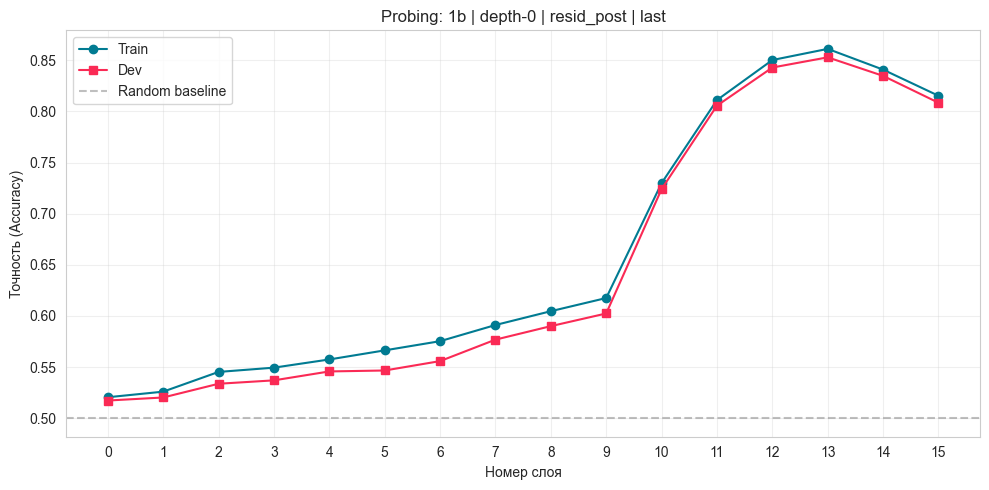

In [18]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

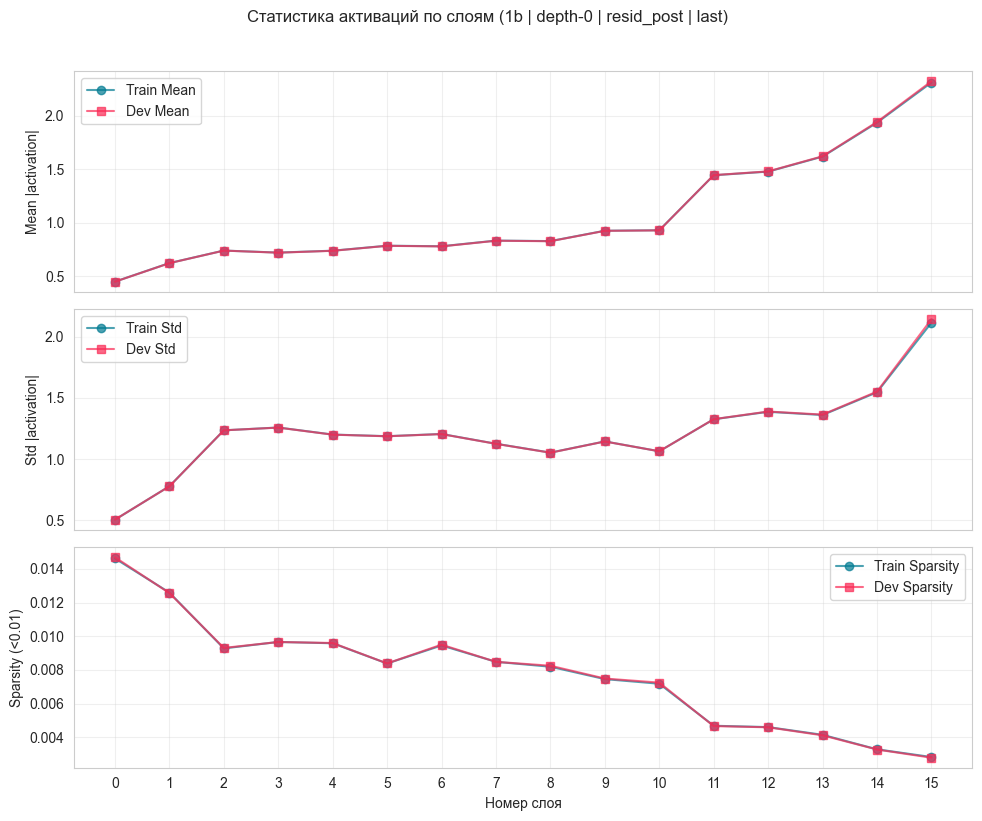

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}(qLoRA)_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [21]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_1b(qLoRA)_depth-0_resid_post_last.json


### Проверка токенизации

In [ ]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [23]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [24]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough....

Токены (первые 50): ['Anne', 'Ġis', 'Ġblue', '.', 'ĠAnne', 'Ġis', 'Ġrough', '.', 'ĠAnne', 'Ġis', 'Ġyoung', '.', 'ĠAll', 'Ġyoung', 'Ġpeople', 'Ġare', 'Ġcold', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġnice', 'Ġthen', 'Ġthey', 'Ġare', 'Ġgreen', '.', 'ĠRough', 'Ġpeople', 'Ġare', 'Ġyoung', '.', 'ĠIf', 'ĠAnne', 'Ġis', 'Ġgreen', 'Ġthen', 'ĠAnne', 'Ġis', 'Ġblue', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġfur', 'ry']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=True, в токенах=True
  'then': в тексте=True, в токенах=True
  'and': в тексте=True, в токенах=True
  'or': в тексте=False, в токенах=False
  'not': в тексте=False, в токенах=False
  'implies': в тексте=False, в токенах=False


In [25]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [6]:
data = load_probing_results(f"{MODEL_SIZE}(qLoRA)", VARIANT, HOOK_NAME, POOLING)

In [7]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-05-05T12:09:45.420515',
  'variant': 'depth-0',
  'model_size': '1b',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 16,
  'max_length': 193},
 'summary': {'best_layer': 13,
  'best_train_acc': 0.8610895519923378,
  'best_dev_acc': 0.8528332186281257,
  'n_layers': 16},
 'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'train_accs': [0.5205343725745991,
  0.5260002972406163,
  0.5452879105636013,
  0.5494657925590766,
  0.5574747758310352,
  0.5663589675842594,
  0.57534223954291,
  0.5911455323084036,
  0.6046534669815216,
  0.6175338936869396,
  0.7298247931700712,
  0.8110540482520601,
  0.8501742160278746,
  0.8610895519923378,
  0.8408111366150899,
  0.8152649569826774],
 'dev_accs': [0.5173204863500803,
  0.5203028217481074,
  0.5337233310392292,
  0.5370497820601056,
  0.5457673778389539,
  0.5466850194998853,
  0.5558614361091994,
  0.5768524891030052,
  0.59004

In [8]:
DIFF_LAYER = data["summary"]["best_layer"]

In [9]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [12]:
diff_stats = compute_differential_stats(
    hooked_model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [13]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0428
Стандартное отклонение разницы: 0.0908


In [14]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 1668: 0.4042
  Нейрон 1638: 0.2885
  Нейрон 232: 0.1948
  Нейрон 1429: 0.1771
  Нейрон 1467: 0.1083
  Нейрон 1559: 0.1021
  Нейрон 1034: 0.0977
  Нейрон 487: 0.0965
  Нейрон 95: 0.0932
  Нейрон 379: 0.0924
  Нейрон 1541: 0.0883
  Нейрон 1878: 0.0861
  Нейрон 1124: 0.0850
  Нейрон 832: 0.0846
  Нейрон 1215: 0.0844
  Нейрон 1032: 0.0844
  Нейрон 431: 0.0821
  Нейрон 1809: 0.0818
  Нейрон 459: 0.0813
  Нейрон 1549: 0.0812
  Нейрон 1968: 0.0810
  Нейрон 458: 0.0809
  Нейрон 1283: 0.0808
  Нейрон 709: 0.0803
  Нейрон 1877: 0.0802
  Нейрон 241: 0.0797
  Нейрон 567: 0.0797
  Нейрон 1009: 0.0792
  Нейрон 1881: 0.0792
  Нейрон 1739: 0.0781
  Нейрон 86: 0.0773
  Нейрон 975: 0.0771
  Нейрон 387: 0.0770
  Нейрон 13: 0.0767
  Нейрон 490: 0.0760
  Нейрон 1930: 0.0758
  Нейрон 1362: 0.0755
  Нейрон 1206: 0.0747
  Нейрон 897: 0.0747
  Нейрон 717: 0.0745
  Нейрон 371: 0.0744
  Нейрон 1851: 0.0742
  Нейрон 504: 0.0741
  Нейрон 1866: 0.0740
  Нейро

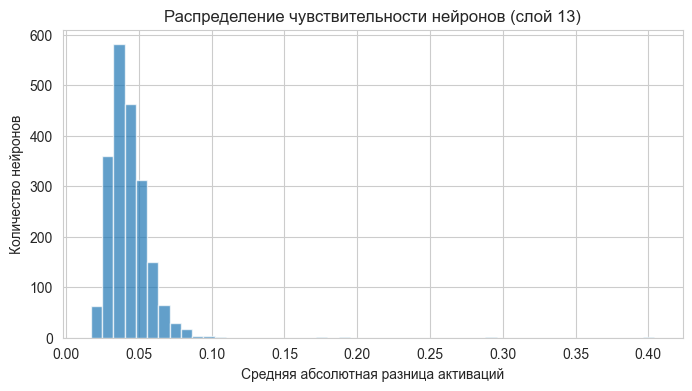

In [15]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [ ]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_1b(qLoRA)_depth-0_resid_post_last.json


In [64]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=DIFF_LAYER, neuron_idx=top_neurons[0],
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [65]:
print(f"Топ-10 примеров для нейрона {top_neurons[0]}:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 1668:
  [6.250] Dave is nice. Fiona is nice. Fiona is white. All rough things are red. Cold, white things are young. Dave is not nice.
  [5.250] The dog eats the lion. The dog is blue. The dog is not cold. The dog is green. The dog is not red. The dog is rough. The dog likes the lion. The dog does not need the lion. The lion eats the dog. The lion is blue. The lion is cold. The lion is green. The lion is red. The lion is not rough. The lion does not like the dog. The lion needs the dog. If the lion is blue and the lion is cold then the lion eats the dog. If the lion eats the dog and the lion is not rough then the lion needs the dog. The dog is not blue.
  [2.250] The mouse is big. The mouse is cold. The mouse is green. The mouse is kind. The mouse is red. If someone is big then they are kind. If someone is big then they are kind. If someone is green then they are cold. All cold, kind people are red. Green people are cold. If the mouse is green then the mouse

In [66]:
print(f"Топ-30 токенов для нейрона {top_neurons[0]}:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 1668:
rin: +72.000
All: +59.603
The: +56.551
cold: +54.730
are: +53.373
round: +53.320
smart: +52.926
is: +52.222
not: +51.968
big: +51.517
young: +51.195
,: +50.153
blue: +49.788
nice: +49.505
ry: +48.855
quiet: +48.176
white: +47.868
Bob: +46.750
Dave: +46.500
Charlie: +46.375
kind: +45.995
green: +45.706
If: +45.480
rough: +45.032
F: +44.889
Gary: +44.750
tiger: +44.735
urry: +44.125
Big: +44.042
then: +43.618


In [31]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-20:][::-1]  # Топ-20
top_scores = [neuron_sens[n] for n in top_neurons]

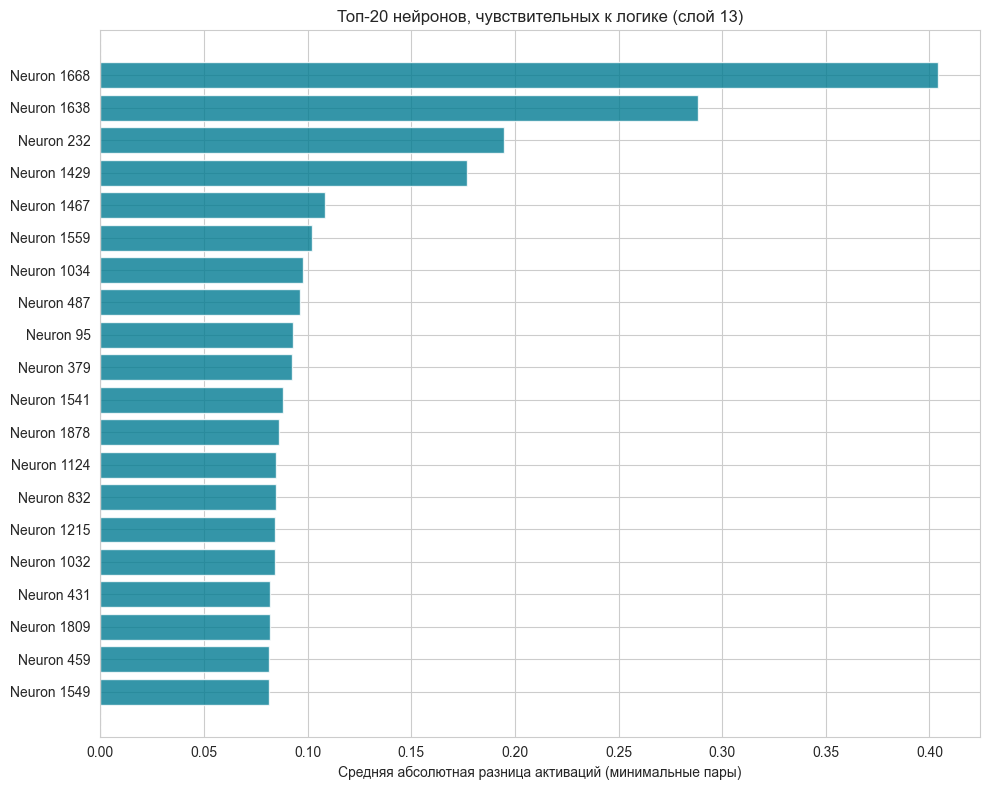

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_neurons))

# Разделяем по знаку средней активации
ax.barh(y_pos, top_scores, color='xkcd:ocean', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"Neuron {n}" for n in top_neurons])
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Средняя абсолютная разница активаций (минимальные пары)")
ax.set_title(f"Топ-20 нейронов, чувствительных к логике (слой {DIFF_LAYER})")
ax.invert_yaxis()  # Лучший нейрон сверху
plt.tight_layout()
plt.show()